In [1]:
import sys

sys.path.append("..")
from src import *

/leonardo_scratch/fast/IscrC_MACRO/CalciumImagingDenoising/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cupy Available= 1


In [2]:
max_frames = 300
dataset = "synthetic"
variant = 150
segment_net = "cellpose"

In [3]:
meta = DATASETS[dataset]

clog(f"blue:Loading recordings...")
x = Recording(meta.x, max_frames=max_frames).np
y_dcad = Recording(f"dataset/{dataset}/deepcad_{variant}/data.tiff", max_frames=max_frames).np
y_f2c = Recording(f"dataset/{dataset}/fft_{variant}/data.tiff", max_frames=max_frames).np
gt = Recording(meta.gt, max_frames=max_frames).np

clog(f"blue:Loading masks...")
mask_dcad = np.load(f"{segment_net}_results/{dataset}/deepcad_{variant}/cpsam_mask.npy")
mask_f2c = np.load(f"{segment_net}_results/{dataset}/fft_{variant}/cpsam_mask.npy")
mask_gt = np.load(f"{segment_net}_results/{dataset}/gt/cpsam_mask.npy")

Loading recordings... [0.6/348.5 GiB] [5s]
Loading masks... [1.1/347.8 GiB] [6s]


In [4]:
class ROI:
    def __init__(self, label, coords: tuple[np.array, np.array], mask):
        self.label = int(label)
        self.coords = np.vstack(coords).T
        self.ys, self.xs = coords
        self.centroid = (self.ys.mean(), self.xs.mean())
        self.area = self.ys.size
        self.mask = mask


# Funs
def mask2rois(mask: np.ndarray) -> list[ROI]:
    rois = []
    H, W = mask.shape
    for label in np.unique(mask):
        ys, xs = np.nonzero(mask == label)
        if ys.size == 0 or label == 0:
            continue
        roi_mask = np.zeros((H, W), dtype=bool)
        roi_mask[ys, xs] = True
        rois.append(ROI(label, (ys, xs), roi_mask))
    return rois


def get_traces(vid: np.ndarray, rois: list[ROI]) -> np.ndarray:
    return np.array([vid[:, r.ys, r.xs].mean(axis=1) for r in rois])

In [5]:
def pairwise_pearson(traces: np.ndarray) -> np.ndarray:
    return np.corrcoef(traces)

def pairwise_distances(rois: list[ROI], pixel_size_um: float=1.0) -> np.ndarray:
    centroids = np.array([r.centroid for r in rois])
    dy = centroids[:, None, 0] - centroids[None, :, 0]
    dx = centroids[:, None, 1] - centroids[None, :, 1]
    return np.sqrt(dx**2 + dy**2) * pixel_size_um

In [6]:
def get_pearsons(vid, mask):
    rois = mask2rois(mask[-1])
    traces = get_traces(vid, rois)

    distances = range(0, 600, 10)
    roi_distances = pairwise_distances(rois)
    roi_pearsons = pairwise_pearson(traces)
    pearsons = {}
    for distance in tqdm(distances):
        pearsons[distance] = []
        for i in range(len(rois)):
            for j in range(len(rois)):
                if i != j and distance - 10 < roi_distances[i, j] <= distance:
                    pearsons[distance].append(roi_pearsons[i, j])

    for k in pearsons.keys():
        pearsons[k] = sum(pearsons[k]) / len(pearsons[k]) if pearsons[k] else 0
        
    return pearsons

In [14]:
rois = mask2rois(mask_dcad[-1])
traces = get_traces(y_dcad, rois)
roi_distances = pairwise_distances(rois)
roi_pearsons = pairwise_pearson(traces)

df = pd.DataFrame(columns=["distance", "correlation"])
df.index.name = "couple"
for i in trange(len(rois)):
    for j in range(len(rois)):
        if i != j:
            df.loc[f"{i}-{j}"] = [roi_distances[i, j], roi_pearsons[i, j]]

100%|██████████| 150/150 [00:18<00:00,  8.23it/s]


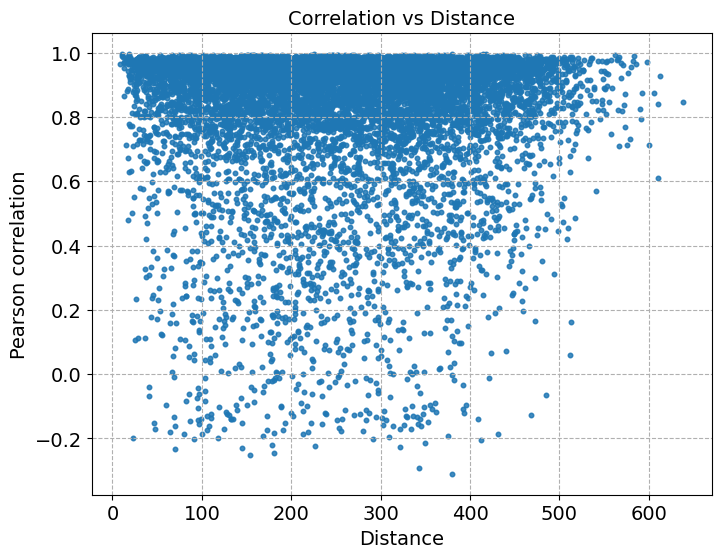

In [22]:
df_sorted = df.sort_values("distance")
plt.figure(figsize=(8,6))
plt.scatter(df_sorted["distance"], df_sorted["correlation"], s=10, alpha=0.6)
plt.xlabel("Distance")
plt.ylabel("Pearson correlation")
plt.title("Correlation vs Distance")
plt.grid(True)
plt.show()


100%|██████████| 60/60 [00:00<00:00, 247.55it/s]


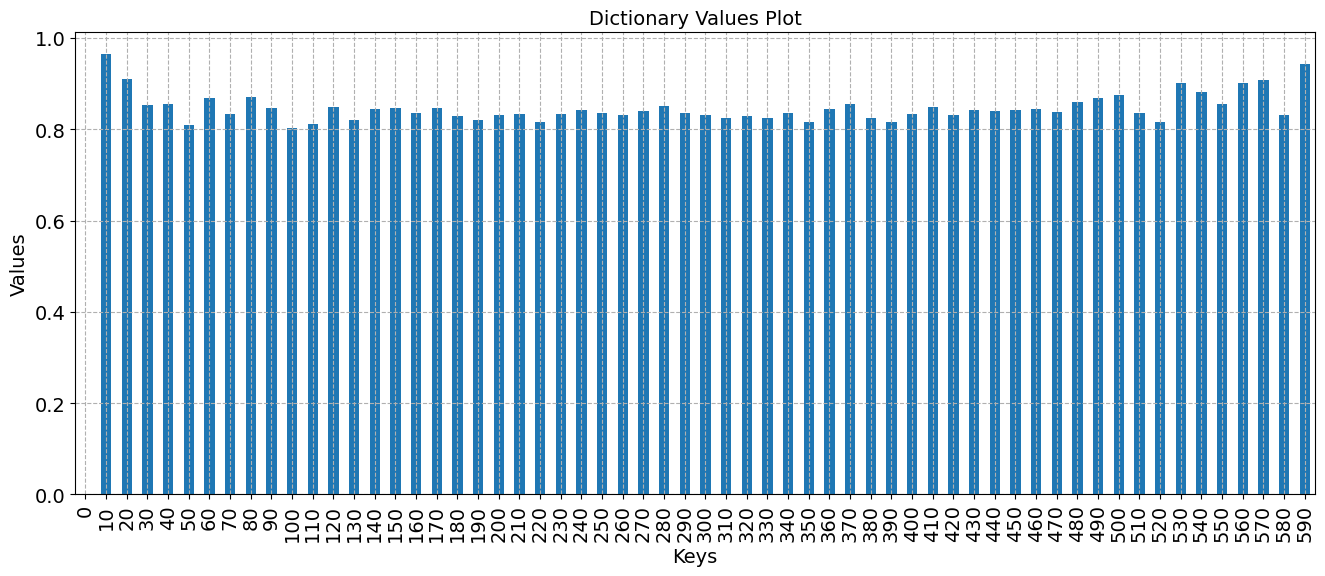

In [7]:
deepcad=get_pearsons(y_dcad,mask_dcad)
pd.Series(deepcad).plot(kind='bar', figsize=(16,6))
plt.title('Dictionary Values Plot')
plt.xlabel('Keys')
plt.ylabel('Values')
plt.show()

In [ ]:
gt=get_pearsons(gt,mask_gt)
pd.Series(gt).plot(kind='bar', figsize=(16,6))
plt.title('Dictionary Values Plot')
plt.xlabel('Keys')
plt.ylabel('Values')
plt.show()